In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the dataset
file_path = 'Titanic.csv'
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
# Drop unnecessary columns
cols_to_drop = ['PassengerId', 'Name', 'Ticket']
df.drop(columns=cols_to_drop, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [65]:
# Convert categorical features to category dtype
cat_cols = ["Survived", "Pclass", "Sex", "SibSp", "Parch", "Embarked"]
df[cat_cols] = df[cat_cols].astype("category")

# Helper function to display data types and unique counts
def get_type_info(dataframe):
    return pd.DataFrame({
        "dtypes": dataframe.dtypes,
        "nunique": dataframe.nunique()
    }).T

get_type_info(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
dtypes,category,category,category,float64,category,category,float64,str,category
nunique,2,3,2,88,7,7,248,147,3


In [66]:
# Drop rows with missing Embarked values and drop Cabin column
df = df.dropna(subset=['Embarked'])
df.drop(columns=["Cabin"], inplace=True)

# Impute missing Age with median
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# Verify missing values summary
null_counts = df.isnull().sum()
null_ratios = (null_counts / len(df)) * 100
pd.DataFrame({"null_count": null_counts, "ratio(%)": null_ratios}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
null_count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio(%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
# Detect outliers in numerical columns
col_num = df.select_dtypes("number").columns

for col in col_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values
    
    print(f"[{col}] Lower Outliers: {len(lower_outliers)}, Upper Outliers: {len(upper_outliers)}")

[Age] Lower Outliers: 24, Upper Outliers: 41
[Fare] Lower Outliers: 0, Upper Outliers: 114


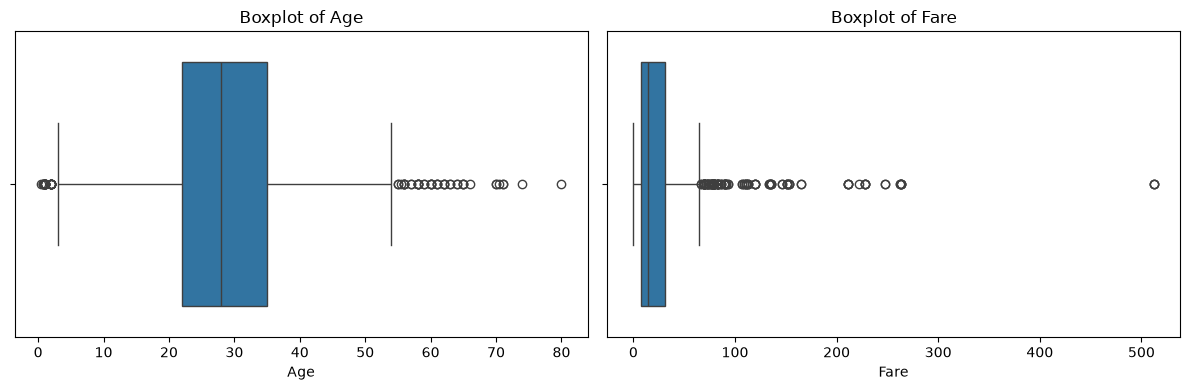

In [68]:
# Plot boxplots for numerical features
plt.figure(figsize=(12, 4))
for i, col in enumerate(col_num):
    plt.subplot(1, len(col_num), i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [69]:
df.duplicate().sum()

AttributeError: 'DataFrame' object has no attribute 'duplicate'

In [70]:
num_col = df.select_dtypes("number").columns

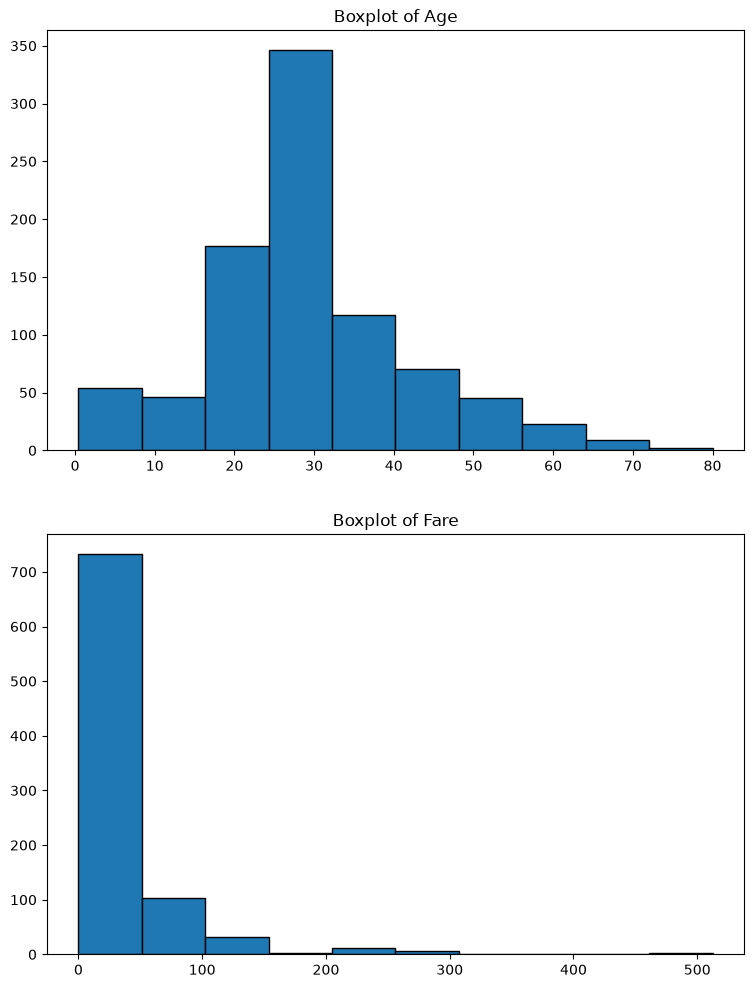

In [71]:
plt.figure(figsize=(9, 12))
for i, col in enumerate(num_col):
    plt.subplot(len(num_col), 1, i + 1)
    plt.hist(df[col], edgecolor='black',)
    plt.title(f"Boxplot of {col}")
plt.show()

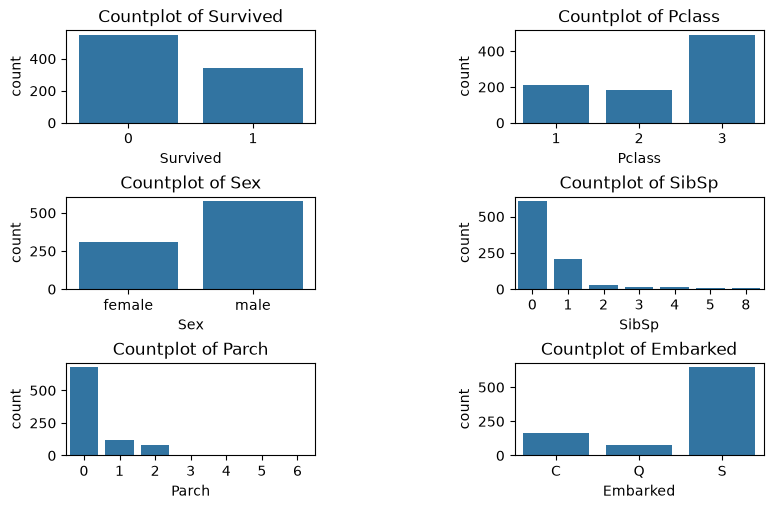

In [85]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(9, 12))
for i, col in enumerate(cat_cols):
    plt.subplot(len(cat_cols), 2, i + 1)
    sns.countplot(x=df[col], data=df)
    plt.title(f"Countplot of {col}")
plt.subplots_adjust(hspace=0.8, wspace=0.8) 

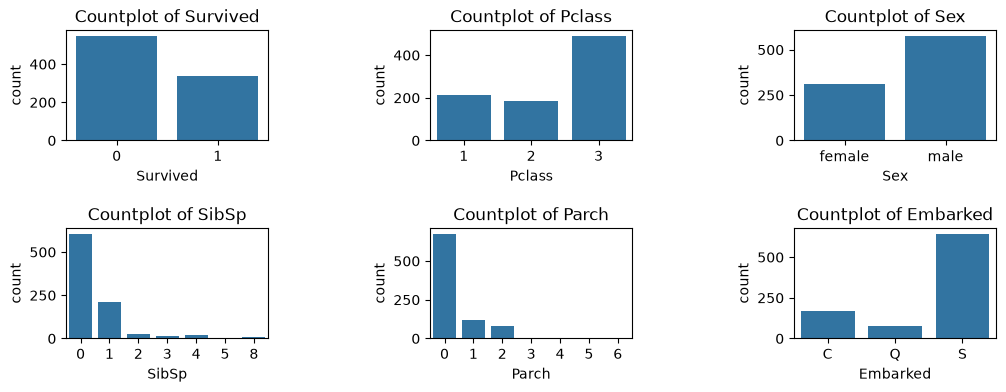

In [89]:
plt.figure(figsize=(12,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=df[col], data=df)
    plt.title(f"Countplot of {col}")
plt.subplots_adjust(hspace=0.8, wspace=0.8)    

Text(0.5, 1.0, 'Scatter plot of Age vs Fare')

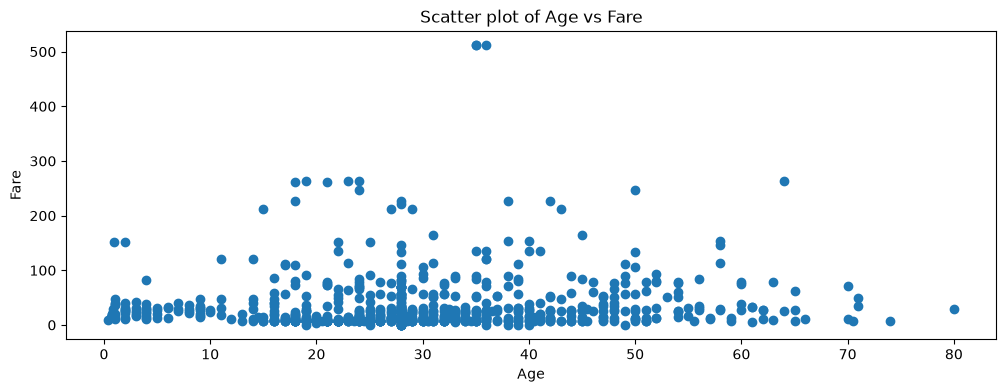

In [91]:
plt.figure(figsize=(12, 4))
plt.scatter(df['Age'], df['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Scatter plot of Age vs Fare")